In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from sklearn.base import clone

# Set plotting style
sns.set_theme(style="whitegrid")

In [18]:
target_col = "gap_ev" # gap_ev or log_p_rdkit #logs logp homo_ev lumo_ev 
seed = 1
test_frac = 0.15

In [19]:
data_path = "/Users/jacknugent/Downloads/alberts_nmr_qchem_merged.pkl"
df = pd.read_pickle(data_path)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")

Loaded dataset with 9599 rows and 136 columns.


In [20]:
df.describe()

,homo_ev,lumo_ev,gap_ev,ionization_ev,elec_affinity_ev,hardness,chem_potential,electrophil_index,num_delta_13C,num_delta_1H,...,nmr_dict_code_25,nmr_dict_code_26,nmr_dict_code_27,nmr_dict_code_28,nmr_dict_code_29,nmr_dict_code_30,nmr_dict_code_31,nmr_h_reconstruction_error,nmr_c_reconstruction_error,nmr_total_reconstruction_error
count,9599.000000,9599.000000,9599.000000,9599.000000,9599.000000,9599.000000,9599.000000,9599.000000,9599.000000,9599.000000,...,9.599000e+03,9.599000e+03,9.599000e+03,9.599000e+03,9.599000e+03,9.599000e+03,9.599000e+03,9599.000000,9599.000000,9599.000000
mean,-8.131548,0.618461,8.750010,8.131548,-0.618461,4.375005,-3.756544,1.677990,17.490676,9.188145,...,1.960592e+00,2.062769e+00,1.887041e+00,1.827203e+00,1.656094e+00,1.740577e+00,1.794937e+00,0.116879,0.146913,0.263793
std,0.599081,0.825669,0.979253,0.599081,0.825669,0.489626,0.529698,0.532415,8.773854,3.373935,...,3.051059e+00,3.012527e+00,2.999331e+00,3.076970e+00,3.318095e+00,3.721486e+00,3.077676e+00,0.037960,0.034320,0.065359
min,-10.421965,-2.589709,4.541038,6.167735,-3.782384,2.270519,-6.025147,0.290843,4.000000,3.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.030093,0.077428,0.124998
25%,-8.533358,0.046259,8.084642,7.706403,-1.114035,4.042321,-4.102866,1.301344,11.000000,7.000000,...,3.935056e-22,4.132429e-07,1.394548e-34,3.974382e-29,3.113616e-37,1.724310e-26,1.353012e-34,0.090098,0.122263,0.216335
50%,-8.091309,0.537153,8.608053,8.091309,-0.537153,4.304027,-3.759254,1.645517,16.000000,9.000000,...,4.346398e-02,7.998250e-01,5.558867e-04,6.267794e-12,1.854906e-17,3.822141e-19,1.055822e-04,0.110193,0.139504,0.251012
75%,-7.706403,1.114035,9.271467,8.533358,-0.046259,4.635733,-3.412377,2.017495,21.000000,11.000000,...,3.030533e+00,3.088303e+00,2.822106e+00,2.870152e+00,2.328757e+00,2.037020e+00,2.686609e+00,0.136075,0.165022,0.297939
max,-6.167735,3.782384,13.547466,10.421965,2.589709,6.773733,-1.766564,5.283517,73.000000,23.000000,...,3.336768e+01,3.113490e+01,2.461790e+01,3.355259e+01,3.805479e+01,3.674381e+01,3.810706e+01,0.315666,0.372549,0.613693


In [21]:
print([column for column in df.columns if 'smiles' in column])

['canonical_smiles']


In [22]:
# An et al. (2014) Eq. 6: 10 selected integration bins + 3 broadness terms
an14_cols = [
    "an14_x0.5", "an14_x1", "an14_x1.5", "an14_x2",
    "an14_x4.5", "an14_x5", "an14_x5.5",
    "an14_x6.5", "an14_x7", "an14_x7.5",
    "an14_b1", "an14_b2", "an14_b3",
]

# Full 24-bin grid (0.5 ppm wide, 0–12 ppm) + broadness + total nH
an14_full_cols = [
    f"an14_x{e}" for e in
    ["0.5", "1", "1.5", "2", "2.5", "3", "3.5", "4",
     "4.5", "5", "5.5", "6", "6.5", "7", "7.5", "8",
     "8.5", "9", "9.5", "10", "10.5", "11", "11.5", "12"]
] + ["an14_b1", "an14_b2", "an14_b3", "an14_total_nH"]

# Summary statistics from NMR peaks
nmr_stats_cols = [
    "num_delta_13C", "num_delta_1H",
    "max_delta_13C", "max_delta_1H",
    "mean_delta_13C",
    "skew_delta_13C", "skew_delta_1H",
    "kurt_delta_13C",
]

nmf_cols = [f"nmr_dict_code_{i:02d}" for i in range(32)] + \
           ["nmr_h_reconstruction_error", "nmr_c_reconstruction_error", "nmr_total_reconstruction_error"]

# 10 ppm bins for 13C NMR
c_bins_10_cols = [
    f"c_x{e}" for e in range(10, 230, 10)
] + ["c_b1", "c_b2", "c_b3", "c_total_nC"]

# 5 ppm bins for 13C NMR
c_bins_5_cols = [
    f"c_x{e}" for e in range(5, 225, 5)
] + ["c_b1", "c_b2", "c_b3", "c_total_nC"]

feature_sets = {
    "an14":              an14_cols,
    "an14_full_initial": an14_full_cols,
    "nmr_stats":         nmr_stats_cols,
    "NMF":               nmf_cols,
    "c_bins_10":                  c_bins_10_cols,
    "c_bins_5":                   c_bins_5_cols,
    "an14_full_with_c_bins_10":   an14_full_cols + c_bins_10_cols,
    "an14_full_with_c_bins_5":    an14_full_cols + c_bins_5_cols,
    "NMF_with_nmr_stats":         nmf_cols + nmr_stats_cols,
    "an14_full_with_nmr_stats":   an14_full_cols + nmr_stats_cols,
    "NMF_with_c_bins_5":          nmf_cols + c_bins_5_cols,
    "NMF_with_an14_full_with_c_bins_5": nmf_cols + an14_full_cols + c_bins_5_cols,
    "NMF_with_nmr_stats_and_an14_full_with_c_bins_5": nmf_cols + nmr_stats_cols + an14_full_cols + c_bins_5_cols,
    "an14_full_with_c_bins_5_and_nmr_stats": an14_full_cols + c_bins_5_cols + nmr_stats_cols,
}

for name, cols in feature_sets.items():
    print(f"Feature set '{name}': {len(cols)} columns")

Feature set 'an14': 13 columns
Feature set 'an14_full_initial': 28 columns
Feature set 'nmr_stats': 8 columns
Feature set 'NMF': 35 columns
Feature set 'c_bins_10': 26 columns
Feature set 'c_bins_5': 48 columns
Feature set 'an14_full_with_c_bins_10': 54 columns
Feature set 'an14_full_with_c_bins_5': 76 columns
Feature set 'NMF_with_nmr_stats': 43 columns
Feature set 'an14_full_with_nmr_stats': 36 columns
Feature set 'NMF_with_c_bins_5': 83 columns
Feature set 'NMF_with_an14_full_with_c_bins_5': 111 columns
Feature set 'NMF_with_nmr_stats_and_an14_full_with_c_bins_5': 119 columns
Feature set 'an14_full_with_c_bins_5_and_nmr_stats': 84 columns


In [23]:
models = {
    # these are templates for the cv run 
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=seed))
    ]),
    "HistGradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=3,
            max_iter=150,
            min_samples_leaf=10,
            l2_regularization=0.1,
            random_state=seed
        ))
    ])
}

In [24]:
def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        "rmse":  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae":   float(mean_absolute_error(y_true, y_pred)),
        "medae": float(median_absolute_error(y_true, y_pred)),
        "r2":    float(r2_score(y_true, y_pred)),
    }

In [25]:
cv = KFold(n_splits=10, shuffle=True, random_state=seed)
results = []

for fs_name, fs_cols in feature_sets.items():
    # 1. Clean missing data for target and features
    model_df = df.dropna(subset=[target_col] + fs_cols)
    X = model_df[fs_cols].astype(float)
    y = model_df[target_col].astype(float)
    
    # 2. Split trainval and test
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=test_frac, random_state=seed
    )
    
    print(f"Feature Set: {fs_name:<28} | Samples: {len(model_df):<4} (TrainVal: {len(X_trainval)}, Test: {len(X_test)})")
    
    for model_name, pipe_template in models.items():
        pipe = clone(pipe_template)
        
        cv_res = cross_validate(
            pipe, X_trainval, y_trainval, cv=cv, 
            scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"]
        )
        cv_rmse = -cv_res["test_neg_root_mean_squared_error"].mean()
        cv_mae = -cv_res["test_neg_mean_absolute_error"].mean()
        cv_r2 = cv_res["test_r2"].mean()
        
        pipe.fit(X_trainval, y_trainval)
        y_pred = pipe.predict(X_test)
        test_metrics = regression_metrics(y_test, y_pred)
        
        results.append({
            "Feature Set": fs_name,
            "N Features": len(fs_cols),
            "Model": model_name,
            "CV RMSE": cv_rmse,
            "CV MAE": cv_mae,
            "CV R²": cv_r2,
            "Test RMSE": test_metrics["rmse"],
            "Test MAE": test_metrics["mae"],
            "Test R²": test_metrics["r2"]
        })

results_df = pd.DataFrame(results)

Feature Set: an14                         | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: an14_full_initial            | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: nmr_stats                    | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: NMF                          | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: c_bins_10                    | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: c_bins_5                     | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: an14_full_with_c_bins_10     | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: an14_full_with_c_bins_5      | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: NMF_with_nmr_stats           | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: an14_full_with_nmr_stats     | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: NMF_with_c_bins_5            | Samples: 9599 (TrainVal: 8159, Test: 1440)
Feature Set: NMF_with_an14_full_with_c_bins

In [26]:

results_df.sort_values(by="Test RMSE")

,Feature Set,N Features,Model,CV RMSE,CV MAE,CV R²,Test RMSE,Test MAE,Test R²
25,NMF_with_nmr_stats_and_an14_full_with_c_bins_5,119,HistGradientBoosting,0.583947,0.447855,0.639864,0.564967,0.442995,0.682950
27,an14_full_with_c_bins_5_and_nmr_stats,84,HistGradientBoosting,0.587054,0.449510,0.635966,0.570878,0.447667,0.676281
17,NMF_with_nmr_stats,43,HistGradientBoosting,0.596314,0.459342,0.624462,0.578791,0.452327,0.667245
24,NMF_with_nmr_stats_and_an14_full_with_c_bins_5,119,ElasticNet,0.600480,0.462542,0.619288,0.580246,0.458362,0.665570
23,NMF_with_an14_full_with_c_bins_5,111,HistGradientBoosting,0.603622,0.461343,0.615131,0.583636,0.454789,0.661651
19,an14_full_with_nmr_stats,36,HistGradientBoosting,0.604066,0.464522,0.614564,0.589569,0.464213,0.654737
15,an14_full_with_c_bins_5,76,HistGradientBoosting,0.603867,0.463945,0.614862,0.593829,0.467114,0.649729
26,an14_full_with_c_bins_5_and_nmr_stats,84,ElasticNet,0.615050,0.473559,0.600485,0.595052,0.472959,0.648285
21,NMF_with_c_bins_5,83,HistGradientBoosting,0.613561,0.469466,0.602404,0.596132,0.463592,0.647007
7,NMF,35,HistGradientBoosting,0.634601,0.486421,0.574675,0.615005,0.479586,0.624303


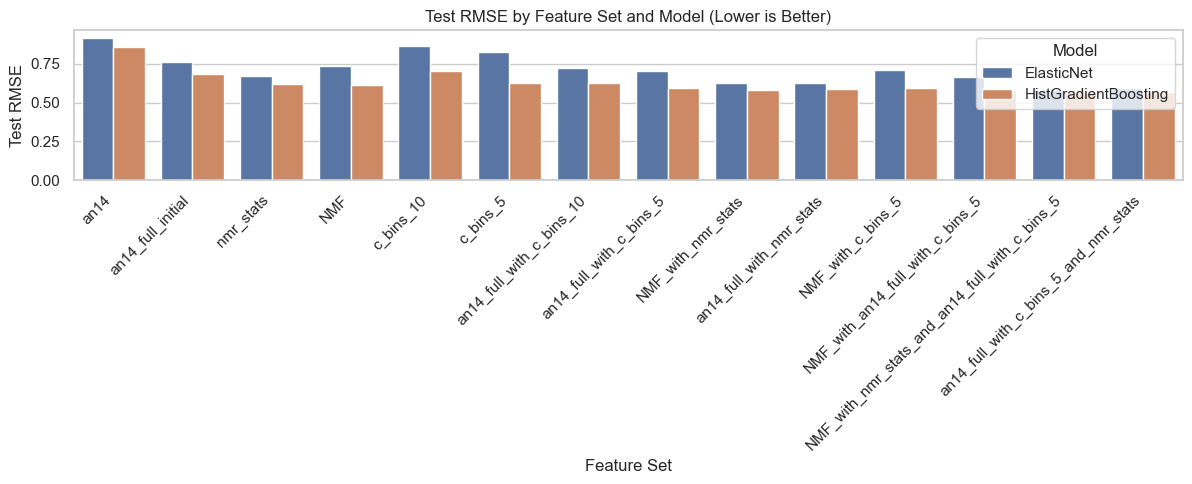

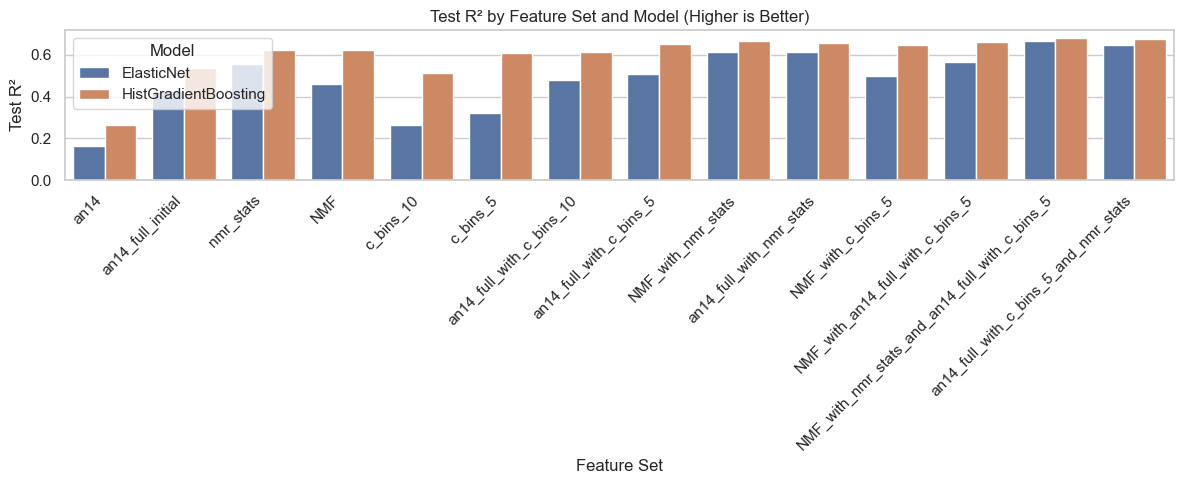

In [27]:
plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x="Feature Set", y="Test RMSE", hue="Model")
plt.xticks(rotation=45, ha='right')
plt.title("Test RMSE by Feature Set and Model (Lower is Better)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x="Feature Set", y="Test R²", hue="Model")
plt.xticks(rotation=45, ha='right')
plt.title("Test R² by Feature Set and Model (Higher is Better)")
plt.tight_layout()

plt.show()

In [28]:
smiles_col_init = 'canonical_smiles'
# Identify best combination based on CV RMSE
best_idx = results_df['CV RMSE'].idxmin()
best_row = results_df.loc[best_idx]
best_fs = best_row['Feature Set']
best_model_name = best_row['Model']

print(f'Best Configuration: {best_fs} with {best_model_name}')

# Re-run best configuration to get actual vs predicted plot
model_df = df.dropna(subset=[target_col] + feature_sets[best_fs])
model_df['smiles'] = model_df[smiles_col_init]
trainval_df, test_df = train_test_split(
    model_df, test_size=test_frac, random_state=seed
)
X_trainval = trainval_df[feature_sets[best_fs]].astype(float)
y_trainval = trainval_df[target_col].astype(float)
X_test = test_df[feature_sets[best_fs]].astype(float)
y_test = test_df[target_col].astype(float)

best_pipe = clone(models[best_model_name])
best_pipe.fit(X_trainval, y_trainval)
y_pred_test = best_pipe.predict(X_test)
y_pred_trainval = best_pipe.predict(X_trainval)

# Helper functions to summarize peaks
def summarize_c_nmr(peaks):
    if not isinstance(peaks, (list, np.ndarray)) or len(peaks) == 0:
        return 'N/A'
    deltas = sorted([p.get('delta (ppm)', p.get('delta', 0)) for p in peaks])
    if len(deltas) <= 6:
        return ', '.join([f'{d:.1f}' for d in deltas])
    else:
        return ', '.join([f'{d:.1f}' for d in deltas[:5]]) + f', ... ({len(deltas)} peaks)'

def summarize_h_nmr(peaks):
    if not isinstance(peaks, (list, np.ndarray)) or len(peaks) == 0:
        return 'N/A'
    sorted_peaks = sorted(peaks, key=lambda x: x.get('delta', x.get('centroid', 0)))
    formatted = []
    for p in sorted_peaks:
        d = p.get('delta', p.get('centroid', 0))
        nh = p.get('nH', 1)
        cat = p.get('category', 's')
        formatted.append(f'{d:.2f} ({nh}H, {cat})')
    if len(formatted) <= 5:
        return ', '.join(formatted)
    else:
        return ', '.join(formatted[:4]) + f', ... ({len(formatted)} peaks)'

# Create combined dataframe for plotting
trainval_plot_df = pd.DataFrame({
    'Actual': y_trainval,
    'Predicted': y_pred_trainval,
    'Set': 'TrainVal (85%)',
    'smiles': trainval_df['smiles'],
    'name': trainval_df['name'] if 'name' in trainval_df.columns else '',
    'Actual gap': y_trainval.map(lambda x: f'{x:.4f} eV'),
    'Predicted gap': pd.Series(y_pred_trainval, index=y_trainval.index).map(lambda x: f'{x:.4f} eV'),
    'Residual': pd.Series(y_pred_trainval - y_trainval.values, index=y_trainval.index).map(lambda x: f'{x:.4f} eV'),
    'C NMR': trainval_df['c_nmr_peaks'].map(summarize_c_nmr),
    'H NMR': trainval_df['h_nmr_peaks'].map(summarize_h_nmr),
    'h_nmr_spectra': trainval_df['h_nmr_spectra'].tolist(),
    'c_nmr_spectra': trainval_df['c_nmr_spectra'].tolist()
})

test_plot_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test,
    'Set': 'Test (15%)',
    'smiles': test_df['smiles'],
    'name': test_df['name'] if 'name' in test_df.columns else '',
    'Actual gap': y_test.map(lambda x: f'{x:.4f} eV'),
    'Predicted gap': pd.Series(y_pred_test, index=y_test.index).map(lambda x: f'{x:.4f} eV'),
    'Residual': pd.Series(y_pred_test - y_test.values, index=y_test.index).map(lambda x: f'{x:.4f} eV'),
    'C NMR': test_df['c_nmr_peaks'].map(summarize_c_nmr),
    'H NMR': test_df['h_nmr_peaks'].map(summarize_h_nmr),
    'h_nmr_spectra': test_df['h_nmr_spectra'].tolist(),
    'c_nmr_spectra': test_df['c_nmr_spectra'].tolist()
})

plot_df = pd.concat([trainval_plot_df, test_plot_df], ignore_index=True)

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output, no_update
import base64
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D

# Create standard plotly figure
fig = px.scatter(
    plot_df, 
    x='Actual', 
    y='Predicted', 
    color='Set',
    title=f'Actual vs Predicted gap_ev (Best Combo: {best_fs} x {best_model_name})',
    labels={'Actual': 'Actual gap_ev', 'Predicted': 'Predicted gap_ev'},
    color_discrete_map={'TrainVal (85%)': '#1f77b4', 'Test (15%)': '#ff7f0e'},
    opacity=0.6
)

# Add y=x diagonal line
min_val = min(plot_df['Actual'].min(), plot_df['Predicted'].min())
max_val = max(plot_df['Actual'].max(), plot_df['Predicted'].max())
fig.add_trace(
    go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode='lines',
        line=dict(color='black', dash='dash', width=2),
        name='Perfect Prediction'
    )
)

fig.update_layout(
    width=800,
    height=800,
    xaxis=dict(scaleanchor='y', scaleratio=1),
    yaxis=dict(constrain='domain'),
    template='plotly_white'
)

# Build custom hover Dash app
h_grid = np.linspace(10.0, -2.0, 10000)
c_grid = np.linspace(230.0, -20.0, 10000)

def make_nmr_plot(grid, intensity, title, color):
    step = max(1, len(grid) // 300)
    x = grid[::step]
    y = intensity[::step]
    sub_fig = go.Figure()
    sub_fig.add_trace(go.Scatter(
        x=x, y=y,
        mode='lines',
        line=dict(color=color, width=1.5),
        hoverinfo='skip'
    ))
    sub_fig.update_layout(
        title=dict(text=title, font=dict(size=10, family='sans-serif'), y=0.9, x=0.5, xanchor='center'),
        margin=dict(l=10, r=10, t=25, b=20),
        xaxis=dict(
            autorange='reversed',
            showticklabels=True,
            tickfont=dict(size=8, family='sans-serif'),
            showgrid=False,
            title=dict(text='ppm', font=dict(size=8, family='sans-serif'))
        ),
        yaxis=dict(
            showticklabels=False,
            showgrid=False,
            zeroline=False
        ),
        width=250,
        height=100,
        template='plotly_white'
    )
    return sub_fig

def add_molecule_hover_app(fig, df, smiles_col, title_col='name', caption_cols=None):
    app = Dash(__name__)
    
    fig_copy = go.Figure(fig)
    fig_copy.update_traces(hoverinfo='none', hovertemplate=None)
    
    app.layout = html.Div([
        dcc.Graph(id='graph-basic-2', figure=fig_copy, clear_on_unhover=True),
        dcc.Tooltip(id='graph-tooltip', background_color='rgba(255, 255, 255, 0.95)')
    ])
    
    @app.callback(
        Output('graph-tooltip', 'show'),
        Output('graph-tooltip', 'bbox'),
        Output('graph-tooltip', 'children'),
        Input('graph-basic-2', 'hoverData')
    )
    def display_hover(hoverData):
        if hoverData is None:
            return False, no_update, no_update
            
        pt = hoverData['points'][0]
        bbox = pt['bbox']
        num = pt['pointNumber']
        curve_num = pt['curveNumber']
        
        trace_name = fig.data[curve_num].name
        df_curve = df[df['Set'] == trace_name].reset_index(drop=True)
        if num < len(df_curve):
            df_row = df_curve.iloc[num]
        else:
            df_row = df.iloc[num]
            
        hoverbox_elements = []
        
        # Drawing of molecule (RDKit SVG)
        smiles = df_row[smiles_col]
        if isinstance(smiles, str):
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                d2d = rdMolDraw2D.MolDraw2DSVG(250, 250)
                opts = d2d.drawOptions()
                opts.clearBackground = False
                d2d.DrawMolecule(mol)
                d2d.FinishDrawing()
                svg_str = d2d.GetDrawingText()
                img_str = f'data:image/svg+xml;base64,{base64.b64encode(svg_str.encode()).decode()}'
                
                hoverbox_elements.append(
                    html.Img(src=img_str, style={'width': '250px', 'display': 'block', 'margin': '0 auto'})
                )
        
        if title_col and title_col in df_row:
            hoverbox_elements.append(
                html.H4(str(df_row[title_col]), style={'margin': '10px 0 5px 0', 'textAlign': 'center', 'fontFamily': 'sans-serif'})
            )
            
        if caption_cols:
            rows = []
            for col in caption_cols:
                if col in df_row and col not in ['h_nmr_spectra', 'c_nmr_spectra']:
                    rows.append(html.Tr([
                        html.Td(html.B(col), style={'padding': '3px 10px 3px 0', 'textAlign': 'left'}),
                        html.Td(str(df_row[col]), style={'padding': '3px 0', 'textAlign': 'left'})
                    ]))
            hoverbox_elements.append(
                html.Table(rows, style={'width': '100%', 'borderCollapse': 'collapse', 'fontFamily': 'sans-serif', 'fontSize': '12px'})
            )
            
        # 1H NMR Plot
        h_spec = df_row.get('h_nmr_spectra')
        if isinstance(h_spec, (list, np.ndarray)) and len(h_spec) > 0:
            h_fig = make_nmr_plot(h_grid, h_spec, '1H NMR Spectrum (Actual)', '#1f77b4')
            hoverbox_elements.append(
                dcc.Graph(figure=h_fig, style={'width': '250px', 'height': '100px', 'marginTop': '10px'}, config={'displayModeBar': False})
            )
            
        # 13C NMR Plot
        c_spec = df_row.get('c_nmr_spectra')
        if isinstance(c_spec, (list, np.ndarray)) and len(c_spec) > 0:
            c_fig = make_nmr_plot(c_grid, c_spec, '13C NMR Spectrum (Actual)', '#d62728')
            hoverbox_elements.append(
                dcc.Graph(figure=c_fig, style={'width': '250px', 'height': '100px', 'marginTop': '10px'}, config={'displayModeBar': False})
            )
            
        return True, bbox, html.Div(hoverbox_elements, style={'padding': '10px', 'width': '270px'})
        
    return app

app = add_molecule_hover_app(
    fig=fig,
    df=plot_df,
    smiles_col='smiles',
    title_col='name',
    caption_cols=['Predicted gap', 'Actual gap', 'Residual', 'C NMR', 'H NMR', 'smiles']
)

app.run(jupyter_mode='inline', port=8700)


Best Configuration: NMF_with_nmr_stats_and_an14_full_with_c_bins_5 with HistGradientBoosting


Total features: 119
Features with non-zero coefficients: 87


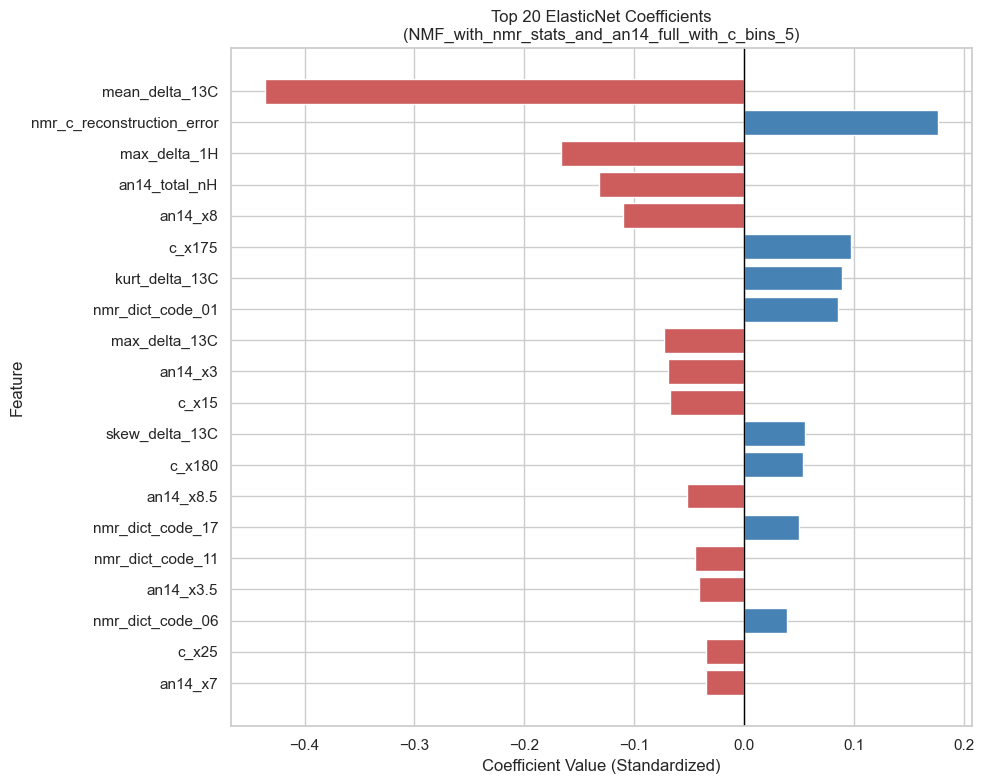

,Feature,Coefficient,Abs_Coefficient
39,mean_delta_13C,-0.436027,0.436027
33,nmr_c_reconstruction_error,0.176813,0.176813
38,max_delta_1H,-0.167086,0.167086
70,an14_total_nH,-0.132224,0.132224
58,an14_x8,-0.110215,0.110215
105,c_x175,0.096995,0.096995
42,kurt_delta_13C,0.089294,0.089294
1,nmr_dict_code_01,0.085767,0.085767
37,max_delta_13C,-0.073061,0.073061
48,an14_x3,-0.069026,0.069026


In [29]:
from sklearn.base import clone

# Choose the feature set you want to analyze
# (e.g., 'NMF_with_nmr_stats_and_an14_full_with_c_bins_5', 'an14_full_with_nmr_stats', etc.)
fs_name = 'NMF_with_nmr_stats_and_an14_full_with_c_bins_5'
fs_cols = feature_sets[fs_name]

# 1. Prepare data identically to the eval loop
model_df = df.dropna(subset=[target_col] + fs_cols)
X = model_df[fs_cols].astype(float)
y = model_df[target_col].astype(float)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=test_frac, random_state=seed
)

# 2. Clone and fit the ElasticNet pipeline from your comparison dictionary
elastic_net_pipe = clone(models["ElasticNet"])
elastic_net_pipe.fit(X_trainval, y_trainval)

# 3. Extract coefficients from the 'model' step of the pipeline
fitted_model = elastic_net_pipe.named_steps["model"]
coefficients = fitted_model.coef_
feature_names = X_trainval.columns

# 4. Create a DataFrame for easy viewing
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient size
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
non_zero_coefs = coef_df[coef_df['Coefficient'] != 0]

print(f"Total features: {len(coef_df)}")
print(f"Features with non-zero coefficients: {len(non_zero_coefs)}")

# 5. Plot the top N coefficients
top_n = 20
top_features = non_zero_coefs.head(top_n)

plt.figure(figsize=(10, 8))
# Reverse order so the largest is at the top of the bar chart
plt.barh(top_features['Feature'][::-1], top_features['Coefficient'][::-1], 
         color=np.where(top_features['Coefficient'][::-1] > 0, 'steelblue', 'indianred'))
plt.xlabel('Coefficient Value (Standardized)')
plt.ylabel('Feature')
plt.title(f'Top {top_n} ElasticNet Coefficients\n({fs_name})')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

# Display the raw dataframe for the top features
display(non_zero_coefs.head(top_n))


In [30]:
smiles_col_init = 'canonical_smiles'
# Identify best combination based on CV RMSE
best_idx = results_df['CV RMSE'].idxmin()
best_row = results_df.loc[best_idx]
best_fs = best_row['Feature Set']
best_model_name = best_row['Model']

print(f'Best Configuration: {best_fs} with {best_model_name}')

# Re-run best configuration to get actual vs predicted plot
model_df = df.dropna(subset=[target_col] + feature_sets[best_fs])
model_df['smiles'] = model_df[smiles_col_init]
trainval_df, test_df = train_test_split(
    model_df, test_size=test_frac, random_state=seed
)
X_trainval = trainval_df[feature_sets[best_fs]].astype(float)
y_trainval = trainval_df[target_col].astype(float)
X_test = test_df[feature_sets[best_fs]].astype(float)
y_test = test_df[target_col].astype(float)

best_pipe = clone(models[best_model_name])
best_pipe.fit(X_trainval, y_trainval)
y_pred_test = best_pipe.predict(X_test)
y_pred_trainval = best_pipe.predict(X_trainval)

# Helper functions to summarize peaks
def summarize_c_nmr(peaks):
    if not isinstance(peaks, (list, np.ndarray)) or len(peaks) == 0:
        return 'N/A'
    deltas = sorted([p.get('delta (ppm)', p.get('delta', 0)) for p in peaks])
    if len(deltas) <= 6:
        return ', '.join([f'{d:.1f}' for d in deltas])
    else:
        return ', '.join([f'{d:.1f}' for d in deltas[:5]]) + f', ... ({len(deltas)} peaks)'

def summarize_h_nmr(peaks):
    if not isinstance(peaks, (list, np.ndarray)) or len(peaks) == 0:
        return 'N/A'
    sorted_peaks = sorted(peaks, key=lambda x: x.get('delta', x.get('centroid', 0)))
    formatted = []
    for p in sorted_peaks:
        d = p.get('delta', p.get('centroid', 0))
        nh = p.get('nH', 1)
        cat = p.get('category', 's')
        formatted.append(f'{d:.2f} ({nh}H, {cat})')
    if len(formatted) <= 5:
        return ', '.join(formatted)
    else:
        return ', '.join(formatted[:4]) + f', ... ({len(formatted)} peaks)'

# Create combined dataframe for plotting
trainval_plot_df = pd.DataFrame({
    'Actual': y_trainval,
    'Predicted': y_pred_trainval,
    'Set': 'TrainVal (85%)',
    'smiles': trainval_df['smiles'],
    'name': trainval_df['name'] if 'name' in trainval_df.columns else '',
    'Actual gap': y_trainval.map(lambda x: f'{x:.4f} eV'),
    'Predicted gap': pd.Series(y_pred_trainval, index=y_trainval.index).map(lambda x: f'{x:.4f} eV'),
    'Residual': pd.Series(y_pred_trainval - y_trainval.values, index=y_trainval.index).map(lambda x: f'{x:.4f} eV'),
    'C NMR': trainval_df['c_nmr_peaks'].map(summarize_c_nmr),
    'H NMR': trainval_df['h_nmr_peaks'].map(summarize_h_nmr),
    'h_nmr_spectra': trainval_df['h_nmr_spectra'].tolist(),
    'c_nmr_spectra': trainval_df['c_nmr_spectra'].tolist()
})

test_plot_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_test,
    'Set': 'Test (15%)',
    'smiles': test_df['smiles'],
    'name': test_df['name'] if 'name' in test_df.columns else '',
    'Actual gap': y_test.map(lambda x: f'{x:.4f} eV'),
    'Predicted gap': pd.Series(y_pred_test, index=y_test.index).map(lambda x: f'{x:.4f} eV'),
    'Residual': pd.Series(y_pred_test - y_test.values, index=y_test.index).map(lambda x: f'{x:.4f} eV'),
    'C NMR': test_df['c_nmr_peaks'].map(summarize_c_nmr),
    'H NMR': test_df['h_nmr_peaks'].map(summarize_h_nmr),
    'h_nmr_spectra': test_df['h_nmr_spectra'].tolist(),
    'c_nmr_spectra': test_df['c_nmr_spectra'].tolist()
})

plot_df = pd.concat([trainval_plot_df, test_plot_df], ignore_index=True)

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output, no_update
import base64
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D

# Create standard plotly figure
fig = px.scatter(
    plot_df, 
    x='Actual', 
    y='Predicted', 
    color='Set',
    title=f'Actual vs Predicted gap_ev (Best Combo: {best_fs} x {best_model_name})',
    labels={'Actual': 'Actual gap_ev', 'Predicted': 'Predicted gap_ev'},
    color_discrete_map={'TrainVal (85%)': '#1f77b4', 'Test (15%)': '#ff7f0e'},
    opacity=0.6
)

# Add y=x diagonal line
min_val = min(plot_df['Actual'].min(), plot_df['Predicted'].min())
max_val = max(plot_df['Actual'].max(), plot_df['Predicted'].max())
fig.add_trace(
    go.Scatter(
        x=[min_val, max_val],
        y=[min_val, max_val],
        mode='lines',
        line=dict(color='black', dash='dash', width=2),
        name='Perfect Prediction'
    )
)

fig.update_layout(
    width=800,
    height=800,
    xaxis=dict(scaleanchor='y', scaleratio=1),
    yaxis=dict(constrain='domain'),
    template='plotly_white'
)

# Build custom hover Dash app
h_grid = np.linspace(10.0, -2.0, 10000)
c_grid = np.linspace(230.0, -20.0, 10000)

def make_nmr_plot(grid, intensity, title, color):
    step = max(1, len(grid) // 300)
    x = grid[::step]
    y = intensity[::step]
    sub_fig = go.Figure()
    sub_fig.add_trace(go.Scatter(
        x=x, y=y,
        mode='lines',
        line=dict(color=color, width=1.5),
        hoverinfo='skip'
    ))
    sub_fig.update_layout(
        title=dict(text=title, font=dict(size=10, family='sans-serif'), y=0.9, x=0.5, xanchor='center'),
        margin=dict(l=10, r=10, t=25, b=20),
        xaxis=dict(
            autorange='reversed',
            showticklabels=True,
            tickfont=dict(size=8, family='sans-serif'),
            showgrid=False,
            title=dict(text='ppm', font=dict(size=8, family='sans-serif'))
        ),
        yaxis=dict(
            showticklabels=False,
            showgrid=False,
            zeroline=False
        ),
        width=250,
        height=100,
        template='plotly_white'
    )
    return sub_fig

def add_molecule_hover_app(fig, df, smiles_col, title_col='name', caption_cols=None):
    app = Dash(__name__)
    
    fig_copy = go.Figure(fig)
    fig_copy.update_traces(hoverinfo='none', hovertemplate=None)
    
    app.layout = html.Div([
        dcc.Graph(id='graph-basic-2', figure=fig_copy, clear_on_unhover=True),
        dcc.Tooltip(id='graph-tooltip', background_color='rgba(255, 255, 255, 0.95)')
    ])
    
    @app.callback(
        Output('graph-tooltip', 'show'),
        Output('graph-tooltip', 'bbox'),
        Output('graph-tooltip', 'children'),
        Input('graph-basic-2', 'hoverData')
    )
    def display_hover(hoverData):
        if hoverData is None:
            return False, no_update, no_update
            
        pt = hoverData['points'][0]
        bbox = pt['bbox']
        num = pt['pointNumber']
        curve_num = pt['curveNumber']
        
        trace_name = fig.data[curve_num].name
        df_curve = df[df['Set'] == trace_name].reset_index(drop=True)
        if num < len(df_curve):
            df_row = df_curve.iloc[num]
        else:
            df_row = df.iloc[num]
            
        hoverbox_elements = []
        
        # Drawing of molecule (RDKit SVG)
        smiles = df_row[smiles_col]
        if isinstance(smiles, str):
            mol = Chem.MolFromSmiles(smiles)
            if mol is not None:
                d2d = rdMolDraw2D.MolDraw2DSVG(250, 250)
                opts = d2d.drawOptions()
                opts.clearBackground = False
                d2d.DrawMolecule(mol)
                d2d.FinishDrawing()
                svg_str = d2d.GetDrawingText()
                img_str = f'data:image/svg+xml;base64,{base64.b64encode(svg_str.encode()).decode()}'
                
                hoverbox_elements.append(
                    html.Img(src=img_str, style={'width': '250px', 'display': 'block', 'margin': '0 auto'})
                )
        
        if title_col and title_col in df_row:
            hoverbox_elements.append(
                html.H4(str(df_row[title_col]), style={'margin': '10px 0 5px 0', 'textAlign': 'center', 'fontFamily': 'sans-serif'})
            )
            
        if caption_cols:
            rows = []
            for col in caption_cols:
                if col in df_row and col not in ['h_nmr_spectra', 'c_nmr_spectra']:
                    rows.append(html.Tr([
                        html.Td(html.B(col), style={'padding': '3px 10px 3px 0', 'textAlign': 'left'}),
                        html.Td(str(df_row[col]), style={'padding': '3px 0', 'textAlign': 'left'})
                    ]))
            hoverbox_elements.append(
                html.Table(rows, style={'width': '100%', 'borderCollapse': 'collapse', 'fontFamily': 'sans-serif', 'fontSize': '12px'})
            )
            
        # 1H NMR Plot
        h_spec = df_row.get('h_nmr_spectra')
        if isinstance(h_spec, (list, np.ndarray)) and len(h_spec) > 0:
            h_fig = make_nmr_plot(h_grid, h_spec, '1H NMR Spectrum (Actual)', '#1f77b4')
            hoverbox_elements.append(
                dcc.Graph(figure=h_fig, style={'width': '250px', 'height': '100px', 'marginTop': '10px'}, config={'displayModeBar': False})
            )
            
        # 13C NMR Plot
        c_spec = df_row.get('c_nmr_spectra')
        if isinstance(c_spec, (list, np.ndarray)) and len(c_spec) > 0:
            c_fig = make_nmr_plot(c_grid, c_spec, '13C NMR Spectrum (Actual)', '#d62728')
            hoverbox_elements.append(
                dcc.Graph(figure=c_fig, style={'width': '250px', 'height': '100px', 'marginTop': '10px'}, config={'displayModeBar': False})
            )
            
        return True, bbox, html.Div(hoverbox_elements, style={'padding': '10px', 'width': '270px'})
        
    return app

app = add_molecule_hover_app(
    fig=fig,
    df=plot_df,
    smiles_col='smiles',
    title_col='name',
    caption_cols=['Predicted gap', 'Actual gap', 'Residual', 'C NMR', 'H NMR', 'smiles']
)

app.run(jupyter_mode='inline', port=8700)


Best Configuration: NMF_with_nmr_stats_and_an14_full_with_c_bins_5 with HistGradientBoosting


Total features: 36
Features with non-zero coefficients: 29


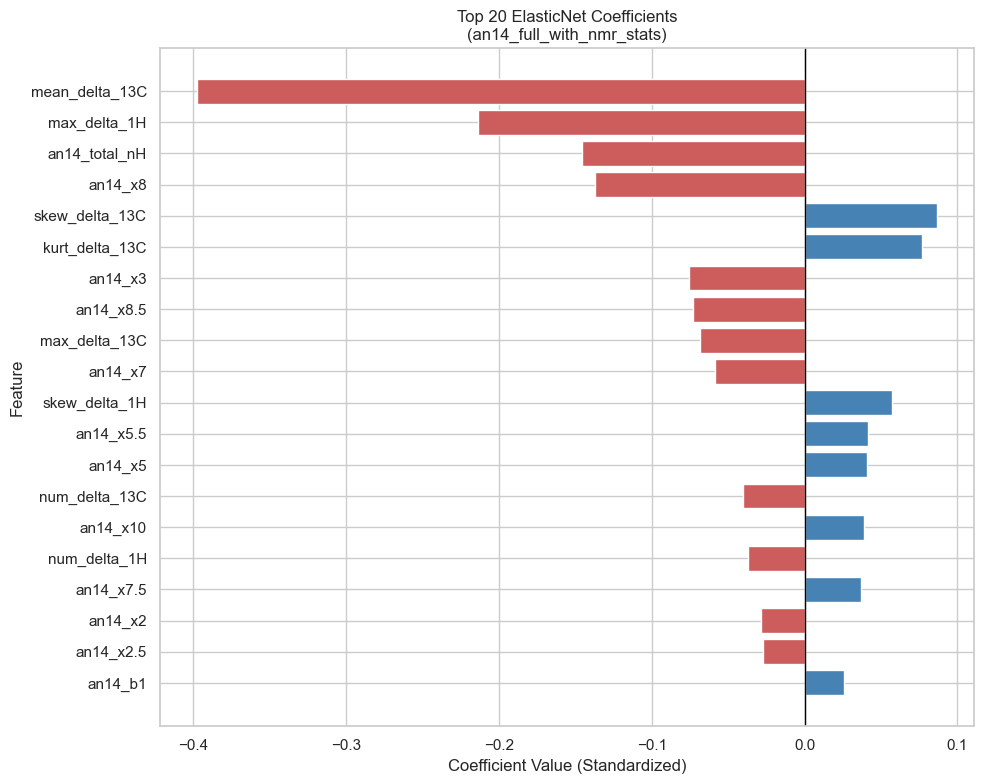

,Feature,Coefficient,Abs_Coefficient
32,mean_delta_13C,-0.397467,0.397467
31,max_delta_1H,-0.213875,0.213875
27,an14_total_nH,-0.145460,0.145460
15,an14_x8,-0.137380,0.137380
33,skew_delta_13C,0.086618,0.086618
35,kurt_delta_13C,0.076731,0.076731
5,an14_x3,-0.075385,0.075385
16,an14_x8.5,-0.073067,0.073067
30,max_delta_13C,-0.068138,0.068138
13,an14_x7,-0.058446,0.058446


In [31]:
from sklearn.base import clone

# Choose the feature set you want to analyze
# (e.g., 'NMF_with_nmr_stats_and_an14_full_with_c_bins_5', 'an14_full_with_nmr_stats', etc.)
fs_name = 'an14_full_with_nmr_stats'
fs_cols = feature_sets[fs_name]

# 1. Prepare data identically to the eval loop
model_df = df.dropna(subset=[target_col] + fs_cols)
X = model_df[fs_cols].astype(float)
y = model_df[target_col].astype(float)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=test_frac, random_state=seed
)

# 2. Clone and fit the ElasticNet pipeline from your comparison dictionary
elastic_net_pipe = clone(models["ElasticNet"])
elastic_net_pipe.fit(X_trainval, y_trainval)

# 3. Extract coefficients from the 'model' step of the pipeline
fitted_model = elastic_net_pipe.named_steps["model"]
coefficients = fitted_model.coef_
feature_names = X_trainval.columns

# 4. Create a DataFrame for easy viewing
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

# Sort by absolute coefficient size
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)
non_zero_coefs = coef_df[coef_df['Coefficient'] != 0]

print(f"Total features: {len(coef_df)}")
print(f"Features with non-zero coefficients: {len(non_zero_coefs)}")

# 5. Plot the top N coefficients
top_n = 20
top_features = non_zero_coefs.head(top_n)

plt.figure(figsize=(10, 8))
# Reverse order so the largest is at the top of the bar chart
plt.barh(top_features['Feature'][::-1], top_features['Coefficient'][::-1], 
         color=np.where(top_features['Coefficient'][::-1] > 0, 'steelblue', 'indianred'))
plt.xlabel('Coefficient Value (Standardized)')
plt.ylabel('Feature')
plt.title(f'Top {top_n} ElasticNet Coefficients\n({fs_name})')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.tight_layout()
plt.show()

# Display the raw dataframe for the top features
display(non_zero_coefs.head(top_n))
